# OEFAF — Governance & Contribution-Review Pipeline (Process Walkthrough)

This notebook is a **narrative, process-only** walkthrough of the **planned** OEFAF contribution, code-review, and security-review pipeline. It reads from governance documents only (`GOVERNANCE.md`, `CONTRIBUTING.md`) and renders a small process diagram. It demonstrates the planned governance process and cross-references the full draft governance and nonprofit plan.

> **Planned / conditional only.** The Open Energy Finance Analytics Foundation (OEFAF) is **in formation as a Section 501(c)(3) public charity**; its Articles of Incorporation have **not** been filed. Everything in this notebook is described in planned and conditional tense. Nothing here is a present-tense claim of incorporation or legal status.

> **Synthetic data only.** Every dataset used in this notebook is *synthetic illustrative data generated for demonstration*. It is **NOT** real agency data and is **NOT** derived from any proprietary or employer source. The notebook performs no network access and uses only public-style, open-source components.

In [1]:
import sys
from pathlib import Path

# Put the oefaf-platform repository root on sys.path so the platform
# component packages (gea, cricat, sdmac, shared) import cleanly no matter
# what working directory this notebook is executed from.
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / 'sdmac' / 'schema_registry').is_dir():
    if _REPO_ROOT == _REPO_ROOT.parent:
        raise RuntimeError('Could not locate the oefaf-platform repo root.')
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print('repo root located:', _REPO_ROOT.name)

repo root located: oefaf-platform


## 1. Source governance documents (read-only)

The pipeline below is sourced entirely from the repository's governance documents — no proprietary or employer process is described.

In [2]:
from shared.utilities.io import repo_root

root = repo_root()
for doc in ['GOVERNANCE.md', 'CONTRIBUTING.md', 'CODE_OF_CONDUCT.md']:
    p = root / doc
    print(f'{doc:<20} present={p.is_file()}  ({p.stat().st_size if p.is_file() else 0} bytes)')

GOVERNANCE.md        present=True  (4331 bytes)
CONTRIBUTING.md      present=True  (4014 bytes)
CODE_OF_CONDUCT.md   present=True  (3074 bytes)


## 2. The planned contribution → review → release pipeline

The planned pipeline has the following stages. Each stage is **conditional** and reflects the policy drafted in `GOVERNANCE.md` and `CONTRIBUTING.md`:

1. **Proposal** — a contributor opens an issue describing the change and the public/openly licensed inputs it would use.
2. **Clean-room / public-data gate** — the contribution must use only public or openly licensed inputs, developed independently of any proprietary system (non-negotiable rule).
3. **Maintainer code review** — at least one maintainer reviews correctness, reproducibility (seeded, offline, Python 3.12), and schema conformance for any registry record types.
4. **Security review (conditional)** — changes touching the API surface, data ingestion, or dependency manifests would receive an additional security review (input validation, dependency provenance, no non-public data paths).
5. **Schema-conformance check** — emitted records would be validated against the SD-MAC schema registry.
6. **Merge & public release** — accepted under the MIT License, intended for public release under the planned OEFAF governance.

Each stage is intended to be overseen, upon incorporation, by the planned board of directors and technical advisory committee described in the draft governance and nonprofit plan.

In [3]:
# The planned pipeline as structured, conditional data (process only).
pipeline_stages = [
    ('Proposal', 'Contributor opens an issue describing the change and its public inputs.'),
    ('Clean-room / public-data gate', 'Public or openly licensed inputs only; clean-room development (non-negotiable).'),
    ('Maintainer code review', 'At least one maintainer reviews correctness, reproducibility, schema conformance.'),
    ('Security review (conditional)', 'API / ingestion / dependency changes get an added security review.'),
    ('Schema-conformance check', 'Emitted records validated against the SD-MAC schema registry.'),
    ('Merge & public release', 'Accepted under MIT; intended for public release under planned OEFAF governance.'),
]
for i, (stage, desc) in enumerate(pipeline_stages, start=1):
    print(f'{i}. {stage}\n   -> {desc}')

1. Proposal
   -> Contributor opens an issue describing the change and its public inputs.
2. Clean-room / public-data gate
   -> Public or openly licensed inputs only; clean-room development (non-negotiable).
3. Maintainer code review
   -> At least one maintainer reviews correctness, reproducibility, schema conformance.
4. Security review (conditional)
   -> API / ingestion / dependency changes get an added security review.
5. Schema-conformance check
   -> Emitted records validated against the SD-MAC schema registry.
6. Merge & public release
   -> Accepted under MIT; intended for public release under planned OEFAF governance.


## 3. Mermaid source for the planned pipeline

The planned pipeline as a Mermaid flowchart (text source — renderable in any Mermaid viewer). All nodes are planned/conditional process steps.

In [4]:
mermaid_src = '''flowchart TD
    A[Proposal: open issue] --> B{Clean-room and public-data gate}
    B -- fails --> X[Cannot be accepted]
    B -- passes --> C[Maintainer code review]
    C --> D{Touches API / ingestion / deps?}
    D -- yes --> E[Security review]
    D -- no --> F[Schema-conformance check]
    E --> F
    F --> G[Merge and public release under MIT]
    G --> H[(Planned OEFAF governance oversight, upon incorporation)]
'''
print(mermaid_src)

flowchart TD
    A[Proposal: open issue] --> B{Clean-room and public-data gate}
    B -- fails --> X[Cannot be accepted]
    B -- passes --> C[Maintainer code review]
    C --> D{Touches API / ingestion / deps?}
    D -- yes --> E[Security review]
    D -- no --> F[Schema-conformance check]
    E --> F
    F --> G[Merge and public release under MIT]
    G --> H[(Planned OEFAF governance oversight, upon incorporation)]



## 4. A simple matplotlib rendering of the planned flow

A lightweight, dependency-free flow rendering so the notebook is self-contained even without a Mermaid renderer.

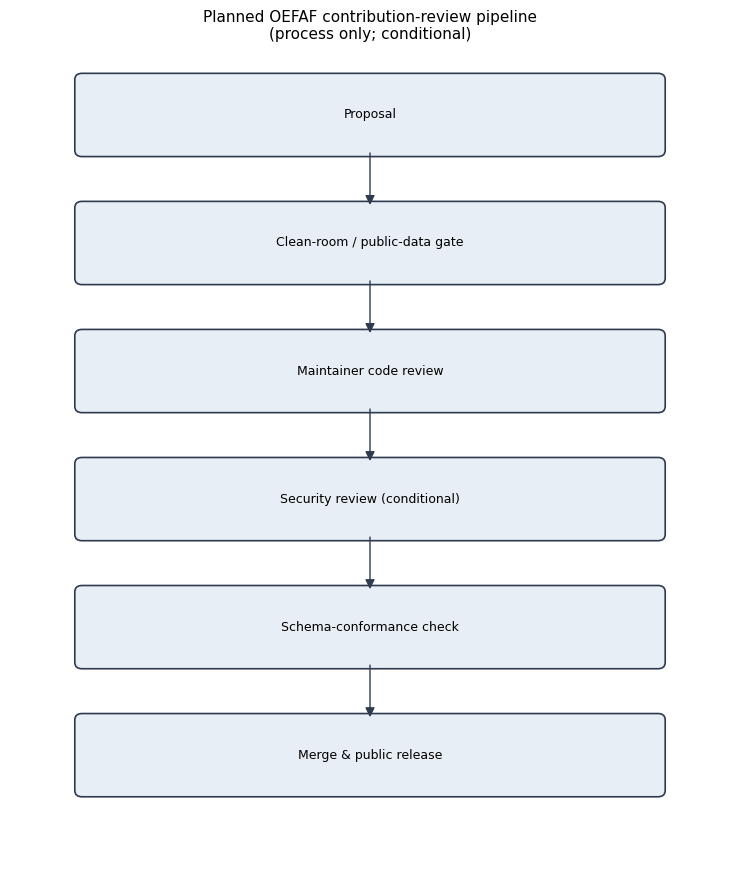

planned-pipeline flow rendered (process only, conditional tense).


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

labels = [s for s, _ in pipeline_stages]
fig, ax = plt.subplots(figsize=(7.5, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(labels) * 2 + 1)
ax.axis('off')
ax.set_title('Planned OEFAF contribution-review pipeline\n(process only; conditional)', fontsize=11)

y = len(labels) * 2
centers = []
for label in labels:
    box = FancyBboxPatch((1.0, y - 0.6), 8.0, 1.1,
                         boxstyle='round,pad=0.1', linewidth=1.2,
                         edgecolor='#2e3b4e', facecolor='#e8eef5')
    ax.add_patch(box)
    ax.text(5.0, y - 0.05, label, ha='center', va='center', fontsize=9)
    centers.append(y - 0.6)
    y -= 2

for top, bottom in zip(centers[:-1], centers[1:], strict=True):
    arrow = FancyArrowPatch((5.0, top), (5.0, bottom + 1.1),
                            arrowstyle='-|>', mutation_scale=14, color='#2e3b4e')
    ax.add_patch(arrow)

plt.tight_layout()
plt.show()
print('planned-pipeline flow rendered (process only, conditional tense).')

---

**Recap.** This notebook described the **planned** OEFAF contribution, code-review, and security-review pipeline as a process walkthrough, sourced from governance documents only, in planned/conditional tense. OEFAF is in formation as a Section 501(c)(3) public charity; its Articles have not been filed. A full draft governance and nonprofit plan accompanies the platform. No proprietary or employer content is used.